# Customer, Product, and Profitability Performance Analysis in Supply Chain Operations

## Organization
APL Logistics (KWE Group)

## Project Objective

To analyze customer profitability, product performance, discount impact, and regional profitability in order to identify key drivers of business value and support profit-focused decision making.

## Business Questions

1. Which customers generate the highest profit?
2. Which customers are loss-making?
3. Which customer segments contribute most to profit?
4. Which products generate the highest revenue and profit?
5. Which product categories have low margins?
6. How do discounts affect profitability?
7. Which markets and regions are most profitable?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("APL_Logistics.csv", encoding='latin1')

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 180519
Columns : 40


In [5]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Product Price',
 'Shipping Mode']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [7]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,21.433241,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


In [8]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum()
})

missing_values = missing_values[
    missing_values['Missing Values'] > 0
]

missing_values.sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values
Customer Lname,8
Customer Zipcode,3


In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [10]:
total_revenue = df['Sales'].sum()

total_profit = df['Order Profit Per Order'].sum()

profit_margin = (
    total_profit /
    total_revenue
) * 100

print("Total Revenue :", round(total_revenue,2))
print("Total Profit :", round(total_profit,2))
print("Profit Margin :", round(profit_margin,2), "%")

Total Revenue : 36784734.31
Total Profit : 3966902.97
Profit Margin : 10.78 %


In [11]:
print("="*50)
print("APL Logistics Dataset Overview")
print("="*50)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nTotal Revenue :", round(df['Sales'].sum(),2))
print("Total Profit :", round(df['Order Profit Per Order'].sum(),2))

print(
    "Profit Margin :",
    round(
        (df['Order Profit Per Order'].sum() /
         df['Sales'].sum()) * 100,
        2
    ),
    "%"
)

APL Logistics Dataset Overview
Rows : 180519
Columns : 40

Total Revenue : 36784734.31
Total Profit : 3966902.97
Profit Margin : 10.78 %


## Data Understanding

The dataset contains transaction-level records related to customers, products, sales, profits, discounts, shipping operations, and market regions.

The dataset will be used to:

- Analyze customer profitability
- Evaluate product and category performance
- Assess discount impact on margins
- Compare profitability across markets and regions

Key business metrics include Sales, Order Profit Per Order, Order Item Discount Rate, Customer Segment, Product Category, Market, and Order Region.

# Data Cleaning & Financial Validation

This phase focuses on:
- Handling missing values
- Validating sales and profit fields
- Validating discount rates
- Creating analytical features
- Preparing a clean dataset for profitability analysis

In [12]:
clean_df = df.copy()

print("Dataset copied successfully")

Dataset copied successfully


In [13]:
clean_df['Customer Lname'] = clean_df[
    'Customer Lname'
].fillna('Unknown')

In [14]:
clean_df['Customer Lname'].isnull().sum()

0

In [15]:
clean_df['Customer Zipcode'] = clean_df[
    'Customer Zipcode'
].fillna(0)

In [16]:
clean_df['Customer Zipcode'].isnull().sum()

0

In [17]:
clean_df.isnull().sum().sum()

0

In [18]:
negative_sales = clean_df[
    clean_df['Sales'] <= 0
]

print("Negative/Zero Sales Records:",
      len(negative_sales))

Negative/Zero Sales Records: 0


In [19]:
negative_total = clean_df[
    clean_df['Order Item Total'] <= 0
]

print(
    "Negative Order Total Records:",
    len(negative_total)
)

Negative Order Total Records: 0


In [20]:
clean_df['Order Profit Per Order'].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.980000
25%           7.000000
50%          31.520000
75%          64.800000
max         911.800000
Name: Order Profit Per Order, dtype: float64

In [21]:
invalid_discount = clean_df[
    (clean_df['Order Item Discount Rate'] < 0)
    |
    (clean_df['Order Item Discount Rate'] > 1)
]

print(
    "Invalid Discount Records:",
    len(invalid_discount)
)

Invalid Discount Records: 0


In [22]:
clean_df['Customer Name'] = (
    clean_df['Customer Fname'].astype(str)
    + ' '
    +
    clean_df['Customer Lname'].astype(str)
)

In [23]:
clean_df[['Customer Name']].head()

,Customer Name
0,Richard Hernandez
1,Mary Barrett
2,Mary Barrett
3,Mary Barrett
4,Mary Barrett


In [24]:
clean_df['Profit Margin %'] = (
    clean_df['Order Profit Per Order']
    /
    clean_df['Sales']
) * 100

In [25]:
clean_df['Profit Margin %'].describe()

count    180519.000000
mean         10.832612
std          42.059373
min        -275.000000
25%           6.224000
50%          24.251213
75%          33.601434
max          50.044287
Name: Profit Margin %, dtype: float64

In [26]:
clean_df['Discount %'] = (
    clean_df['Order Item Discount Rate']
    * 100
)

In [27]:
clean_df['Discount %'].describe()

count    180519.000000
mean         10.166819
std           7.041521
min           0.000000
25%           4.000000
50%          10.000000
75%          16.000000
max          25.000000
Name: Discount %, dtype: float64

In [28]:
clean_df['Shipping Delay'] = (
    clean_df['Days for shipping (real)']
    -
    clean_df['Days for shipment (scheduled)']
)

In [29]:
clean_df['Shipping Delay'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping Delay, dtype: float64

In [30]:
print(clean_df.shape)

(180519, 44)


In [31]:
clean_df.to_csv(
    "cleaned_APL_Logistics.csv",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [32]:
total_revenue = clean_df['Sales'].sum()

total_profit = clean_df['Order Profit Per Order'].sum()

profit_margin = (
    total_profit /
    total_revenue
) * 100

print(f"Revenue: ${total_revenue:,.2f}")
print(f"Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Revenue: $36,784,734.31
Profit: $3,966,902.97
Profit Margin: 10.78%


# Revenue & Profit Overview

This section evaluates the overall financial performance of APL Logistics by analyzing revenue, profit, and profitability metrics.

In [33]:
total_revenue = clean_df['Sales'].sum()

total_profit = clean_df['Order Profit Per Order'].sum()

profit_margin = (
    total_profit /
    total_revenue
) * 100

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Revenue: $36,784,734.31
Total Profit: $3,966,902.97
Profit Margin: 10.78%


In [34]:
kpi_df = pd.DataFrame({
    'Metric': [
        'Revenue',
        'Profit'
    ],
    'Value': [
        total_revenue,
        total_profit
    ]
})

kpi_df

,Metric,Value
0,Revenue,36784734.31
1,Profit,3966902.97


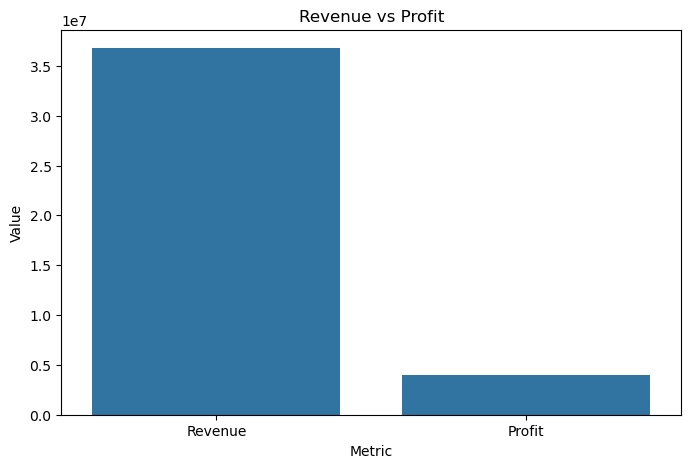

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=kpi_df,
    x='Metric',
    y='Value'
)

plt.title("Revenue vs Profit")
plt.show()

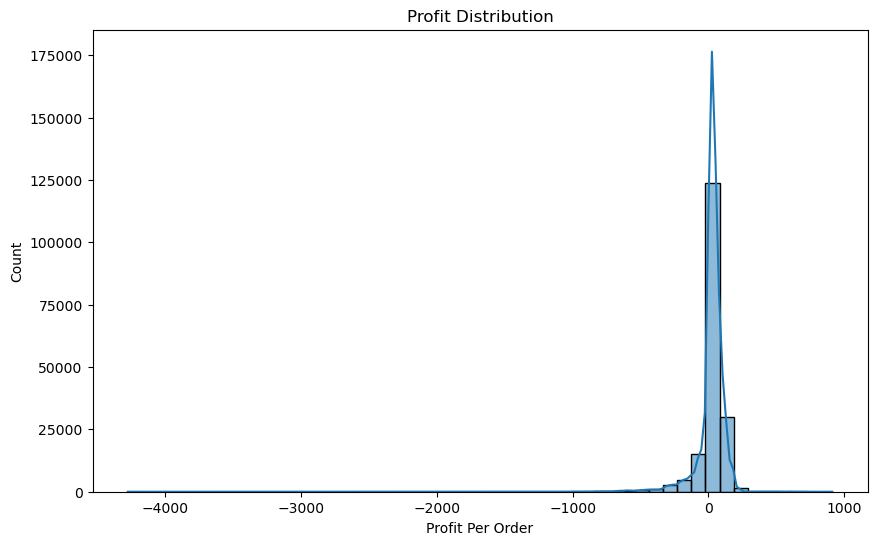

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    clean_df['Order Profit Per Order'],
    bins=50,
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit Per Order")
plt.show()

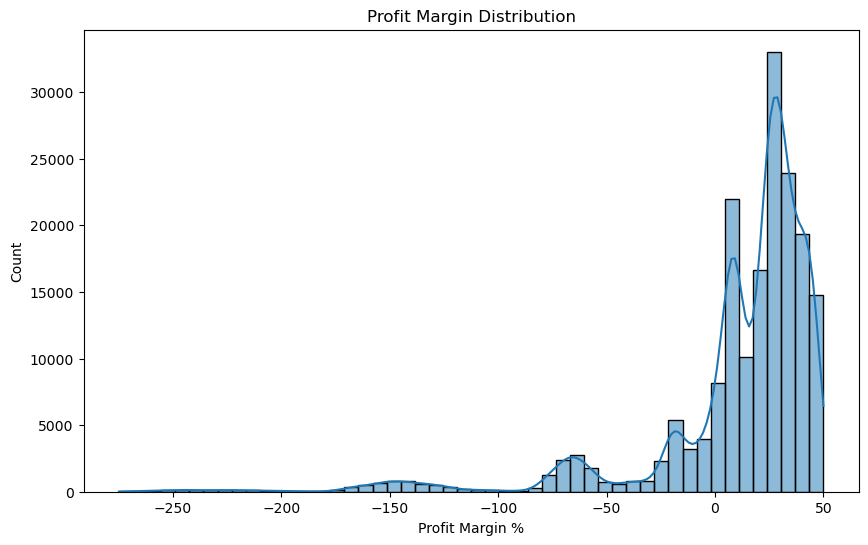

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    clean_df['Profit Margin %'],
    bins=50,
    kde=True
)

plt.title("Profit Margin Distribution")
plt.show()

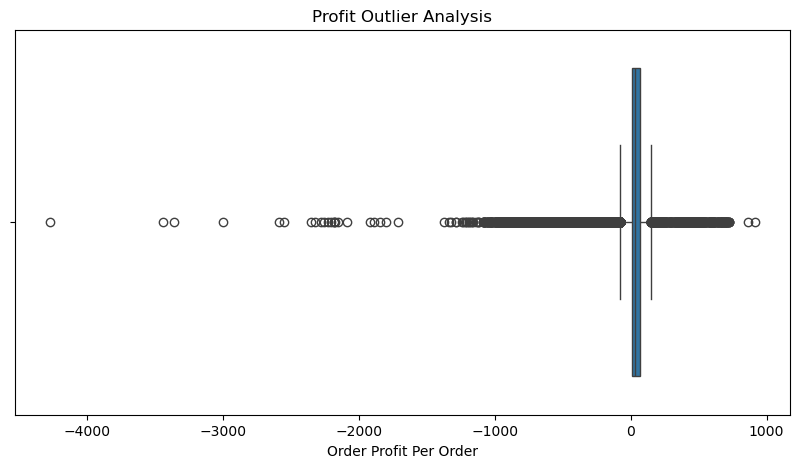

In [38]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=clean_df['Order Profit Per Order']
)

plt.title("Profit Outlier Analysis")
plt.show()

In [39]:
top_revenue_orders = clean_df[
    [
        'Customer Name',
        'Product Name',
        'Sales',
        'Order Profit Per Order'
    ]
].sort_values(
    by='Sales',
    ascending=False
)

top_revenue_orders.head(10)

,Customer Name,Product Name,Sales,Order Profit Per Order
35671,Phillip Smith,SOLE E35 Elliptical,1999.99,864.00
143213,Teresa Gray,SOLE E35 Elliptical,1999.99,34.80
83124,Daniel Smith,SOLE E35 Elliptical,1999.99,660.00
91112,Amber Sheppard,SOLE E35 Elliptical,1999.99,139.50
131583,Victoria Smith,SOLE E35 Elliptical,1999.99,45.00
5217,Mary Lane,SOLE E35 Elliptical,1999.99,-952.56
13617,Catherine Hawkins,SOLE E35 Elliptical,1999.99,-1246.09
15793,Mary Anderson,SOLE E35 Elliptical,1999.99,721.60
76906,Mary Harrison,SOLE E35 Elliptical,1999.99,911.80
16778,Richard Perry,SOLE E35 Elliptical,1999.99,473.20


In [40]:
top_profit_orders = clean_df[
    [
        'Customer Name',
        'Product Name',
        'Sales',
        'Order Profit Per Order'
    ]
].sort_values(
    by='Order Profit Per Order',
    ascending=False
)

top_profit_orders.head(10)

,Customer Name,Product Name,Sales,Order Profit Per Order
76906,Mary Harrison,SOLE E35 Elliptical,1999.99,911.80
35671,Phillip Smith,SOLE E35 Elliptical,1999.99,864.00
15793,Mary Anderson,SOLE E35 Elliptical,1999.99,721.60
173872,Molly Gilliam,Dell Laptop,1500.00,720.30
174000,Zenaida Woodward,Dell Laptop,1500.00,720.00
173982,Olga Mcintosh,Dell Laptop,1500.00,720.00
174015,Nayda Kidd,Dell Laptop,1500.00,712.95
173850,Patricia Chaney,Dell Laptop,1500.00,708.75
174016,Jane Baker,Dell Laptop,1500.00,705.60
173998,Bo Anthony,Dell Laptop,1500.00,705.60


In [41]:
clean_df['Sales'].describe()

count    180519.000000
mean        203.772092
std         132.273075
min           9.990000
25%         119.980000
50%         199.920000
75%         299.950000
max        1999.990000
Name: Sales, dtype: float64

## Revenue & Profit Insights

- The company generated approximately $36.78 million in revenue.
- Total profit was approximately $3.97 million.
- Overall profit margin was approximately 10.8%.
- Profitability is significantly lower than revenue growth, indicating potential margin erosion due to discounts, shipping costs, or low-margin products.
- Further analysis is required to identify high-value customers and profitable product categories.

# Customer Profitability Analysis

This section identifies high-value customers, loss-making customers, and customer segments contributing most to profitability.

In [42]:
customer_analysis = clean_df.groupby(
    'Customer Id'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum',
    'Order Item Quantity':'sum'
}).reset_index()

customer_analysis.head()

,Customer Id,Sales,Order Profit Per Order,Order Item Quantity
0,1,499.95,159.69,5
1,2,1819.73,208.74,19
2,3,3537.68,334.49,33
3,4,1719.63,-439.98,34
4,5,1274.75,309.85,18


In [43]:
customer_names = clean_df[
    ['Customer Id','Customer Name']
].drop_duplicates()

customer_analysis = customer_analysis.merge(
    customer_names,
    on='Customer Id',
    how='left'
)

customer_analysis.head()

,Customer Id,Sales,Order Profit Per Order,Order Item Quantity,Customer Name
0,1,499.95,159.69,5,Richard Hernandez
1,2,1819.73,208.74,19,Mary Barrett
2,3,3537.68,334.49,33,Ann Smith
3,4,1719.63,-439.98,34,Mary Jones
4,5,1274.75,309.85,18,Robert Hudson


In [44]:
customer_analysis['Customer Value Index'] = (
    customer_analysis['Order Profit Per Order']
    /
    customer_analysis['Order Profit Per Order'].sum()
) * 100

In [45]:
top_customers = customer_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
)

top_customers.head(10)

,Customer Id,Sales,Order Profit Per Order,Order Item Quantity,Customer Name,Customer Value Index
2612,2641,9130.92,2441.97,90,Betty Spears,0.061559
1636,1657,9223.71,2196.92,111,Betty Phillips,0.055381
9755,9833,6059.38,1938.39,48,Jacob Smith,0.048864
2597,2626,6274.36,1928.57,55,Laura Smith,0.048617
4958,5004,8164.70,1917.99,114,Dorothy Friedman,0.048350
3697,3735,6019.33,1906.36,61,Mary Lewis,0.048057
741,749,7649.38,1855.15,64,Jesse Matthews,0.046766
5509,5560,6528.21,1831.46,74,Mary Rodriguez,0.046169
10875,10967,5734.41,1822.33,64,Alexander Cunningham,0.045938
5007,5053,7411.32,1813.34,67,Mary Smith,0.045712


In [46]:
bottom_customers = customer_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=True
)

bottom_customers.head(10)

,Customer Id,Sales,Order Profit Per Order,Order Item Quantity,Customer Name,Customer Value Index
1410,1428,3883.67,-3868.56,28,Mary Clark,-0.097521
13980,14086,1500.00,-3442.50,1,Nelle Hyde,-0.086781
18003,18109,1500.00,-3366.00,1,Donna Espinoza,-0.084852
14207,14313,1500.00,-3000.00,1,Jorden Pate,-0.075626
17955,18061,1500.00,-2592.00,1,Imani Conway,-0.065341
14007,14113,1500.00,-2550.00,1,Rinah Landry,-0.064282
13984,14090,1500.00,-2351.25,1,Selma Melton,-0.059272
14292,14398,1500.00,-2328.00,1,Rylee Hardin,-0.058686
14200,14306,1500.00,-2280.00,1,Orli Mcmillan,-0.057476
14130,14236,1500.00,-2255.25,1,Alice Barker,-0.056852


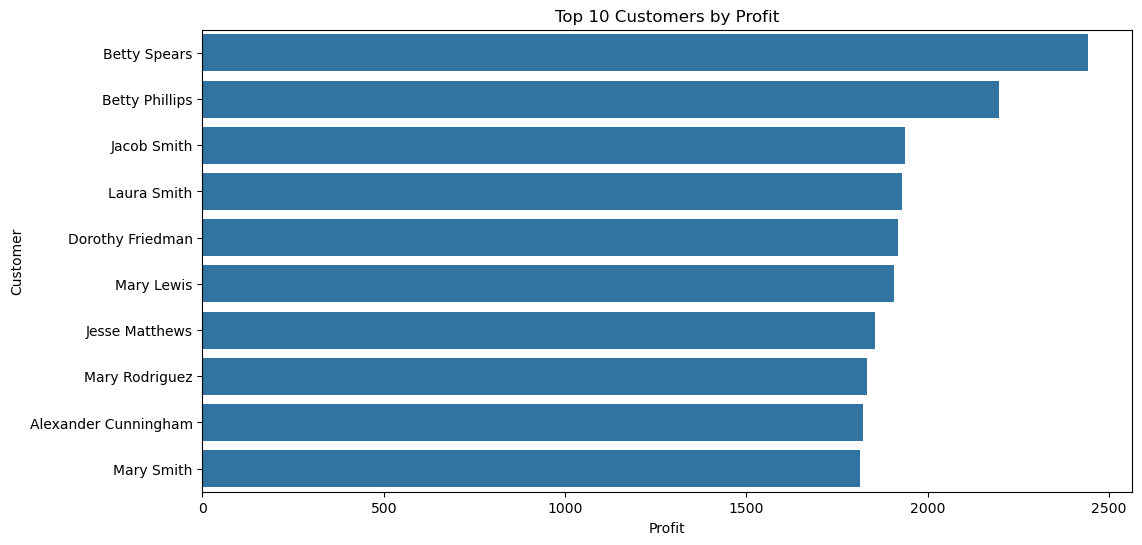

In [47]:
top10 = top_customers.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Order Profit Per Order',
    y='Customer Name'
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")
plt.ylabel("Customer")
plt.show()

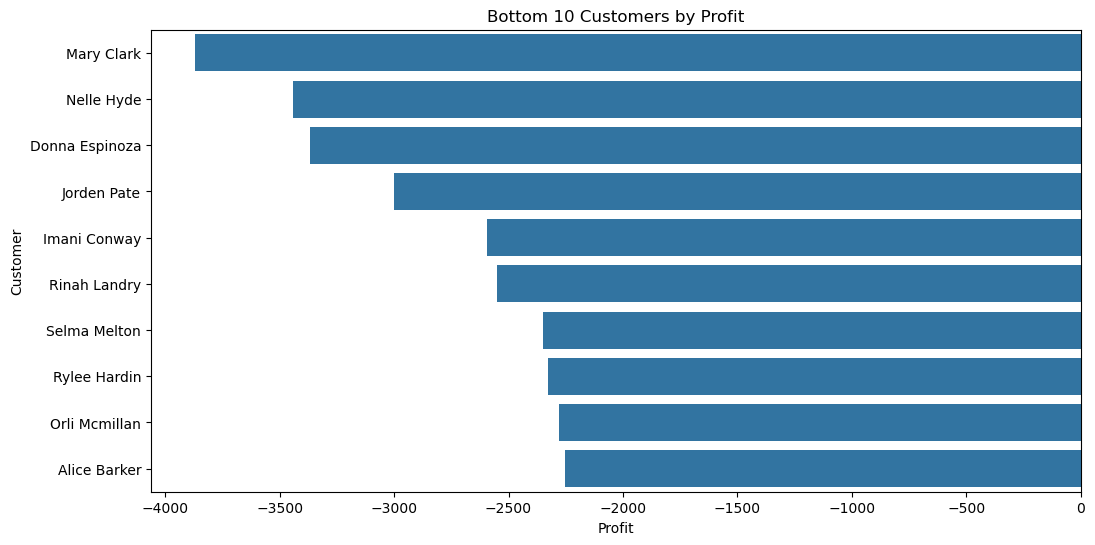

In [48]:
bottom10 = bottom_customers.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10,
    x='Order Profit Per Order',
    y='Customer Name'
)

plt.title("Bottom 10 Customers by Profit")
plt.xlabel("Profit")
plt.ylabel("Customer")
plt.show()

In [49]:
segment_analysis = clean_df.groupby(
    'Customer Segment'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

segment_analysis

,Customer Segment,Sales,Order Profit Per Order
0,Consumer,19095789.79,2073487.67
1,Corporate,11168406.63,1202574.96
2,Home Office,6520537.89,690840.34


In [50]:
segment_analysis['Profit Margin %'] = (
    segment_analysis['Order Profit Per Order']
    /
    segment_analysis['Sales']
) * 100

segment_analysis

,Customer Segment,Sales,Order Profit Per Order,Profit Margin %
0,Consumer,19095789.79,2073487.67,10.858350
1,Corporate,11168406.63,1202574.96,10.767650
2,Home Office,6520537.89,690840.34,10.594837


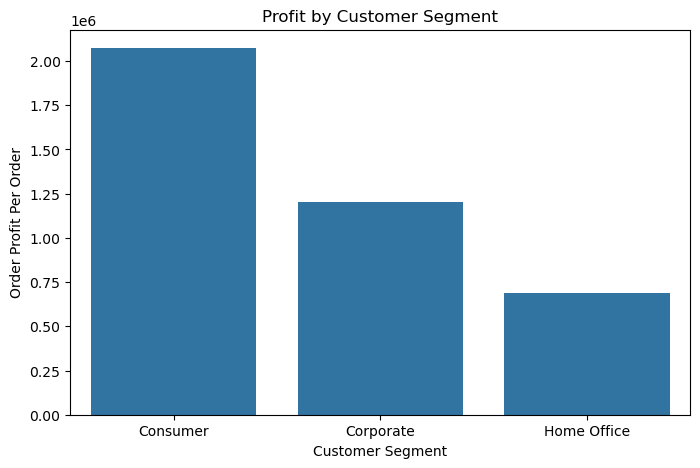

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis,
    x='Customer Segment',
    y='Order Profit Per Order'
)

plt.title("Profit by Customer Segment")
plt.show()

In [52]:
customer_analysis['Tier'] = pd.qcut(
    customer_analysis['Order Profit Per Order'],
    q=4,
    labels=[
        'Bronze',
        'Silver',
        'Gold',
        'Platinum'
    ]
)

customer_analysis['Tier'].value_counts()

Tier
Silver      5165
Bronze      5163
Platinum    5163
Gold        5161
Name: count, dtype: int64

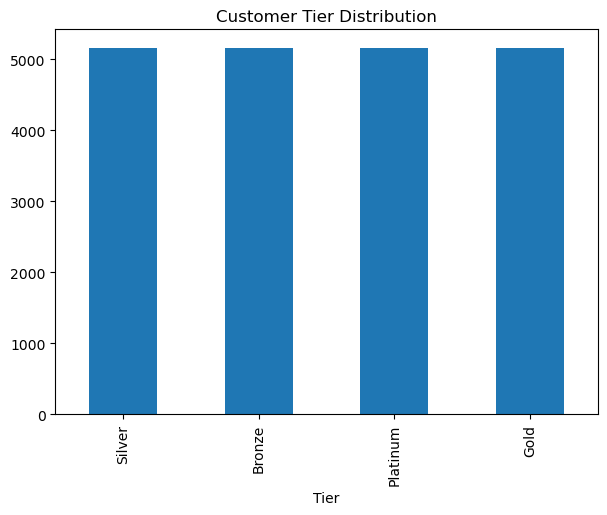

In [53]:
plt.figure(figsize=(7,5))

customer_analysis['Tier'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Tier Distribution")
plt.show()

## Customer Profitability Insights

1. Betty Spears is the highest profit-generating customer with a total profit contribution of 2441.97.
2. Several customers generate substantial losses, with Mary Clark contributing the highest loss (-3868.56).
3. The Consumer segment is the most valuable customer segment, generating approximately $2.07 million in profit.
4. Customer profitability varies significantly, indicating the need for customer-level pricing and retention strategies.
5. Loss-making customers should be reviewed to identify excessive discounting or operational inefficiencies.

# Product & Category Profitability Analysis

This section evaluates product and category performance to identify high-margin and low-margin offerings.

In [54]:
category_analysis = clean_df.groupby(
    'Category Name'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

category_analysis.head()

,Category Name,Sales,Order Profit Per Order
0,Accessories,133671.51,16643.52
1,As Seen on TV!,20597.94,714.43
2,Baby,12229.56,1525.03
3,Baseball & Softball,94057.15,12762.13
4,Basketball,27099.33,1845.67


In [55]:
category_analysis['Margin %'] = (
    category_analysis['Order Profit Per Order']
    /
    category_analysis['Sales']
) * 100

category_analysis.head()

,Category Name,Sales,Order Profit Per Order,Margin %
0,Accessories,133671.51,16643.52,12.451060
1,As Seen on TV!,20597.94,714.43,3.468454
2,Baby,12229.56,1525.03,12.470032
3,Baseball & Softball,94057.15,12762.13,13.568485
4,Basketball,27099.33,1845.67,6.810759


In [56]:
top_revenue_categories = category_analysis.sort_values(
    by='Sales',
    ascending=False
)

top_revenue_categories.head(10)

,Category Name,Sales,Order Profit Per Order,Margin %
18,Fishing,6929653.50,756220.76,10.912822
12,Cleats,4431942.66,494636.92,11.160725
9,Camping & Hiking,4118425.42,427455.57,10.379102
10,Cardio Equipment,3694843.20,383011.10,10.366099
47,Women's Apparel,3147800.00,350421.03,11.132252
46,Water Sports,3113844.60,325146.96,10.441978
34,Men's Footwear,2891757.54,311902.82,10.785926
30,Indoor/Outdoor Games,2888993.94,318451.43,11.022918
38,Shop By Sport,1309522.02,129813.96,9.913080
13,Computers,663000.00,69656.81,10.506306


In [57]:
top_profit_categories = category_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
)

top_profit_categories.head(10)

,Category Name,Sales,Order Profit Per Order,Margin %
18,Fishing,6929653.50,756220.76,10.912822
12,Cleats,4431942.66,494636.92,11.160725
9,Camping & Hiking,4118425.42,427455.57,10.379102
10,Cardio Equipment,3694843.20,383011.10,10.366099
47,Women's Apparel,3147800.00,350421.03,11.132252
46,Water Sports,3113844.60,325146.96,10.441978
30,Indoor/Outdoor Games,2888993.94,318451.43,11.022918
34,Men's Footwear,2891757.54,311902.82,10.785926
38,Shop By Sport,1309522.02,129813.96,9.913080
13,Computers,663000.00,69656.81,10.506306


In [61]:
lowest_margin_categories = category_analysis.sort_values(
    by='Margin %',
    ascending=True
)

lowest_margin_categories.head(10)

,Category Name,Sales,Order Profit Per Order,Margin %
41,Strength Training,54895.53,332.31,0.605350
1,As Seen on TV!,20597.94,714.43,3.468454
33,Men's Clothing,43856.80,2006.04,4.574068
4,Basketball,27099.33,1845.67,6.810759
5,Books,12587.40,883.01,7.015031
45,Video Games,33310.50,2717.52,8.158148
16,DVDs,79395.54,6655.43,8.382625
37,Pet Supplies,41524.80,3589.26,8.643654
27,Health and Beauty,106080.48,9493.63,8.949460
31,Kids' Golf Clubs,98797.58,9045.84,9.155933


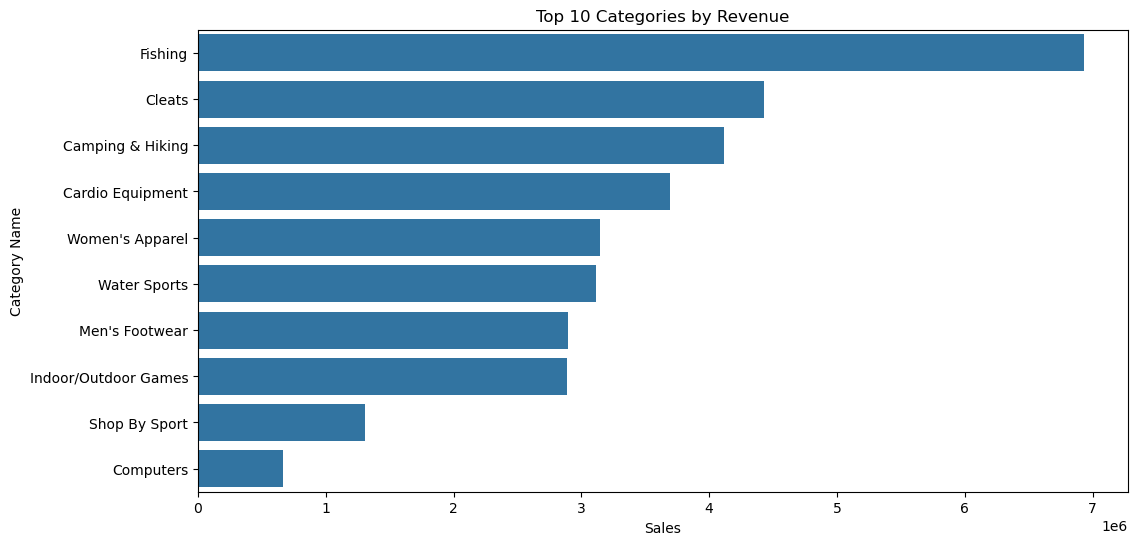

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_revenue_categories.head(10),
    x='Sales',
    y='Category Name'
)

plt.title("Top 10 Categories by Revenue")
plt.show()

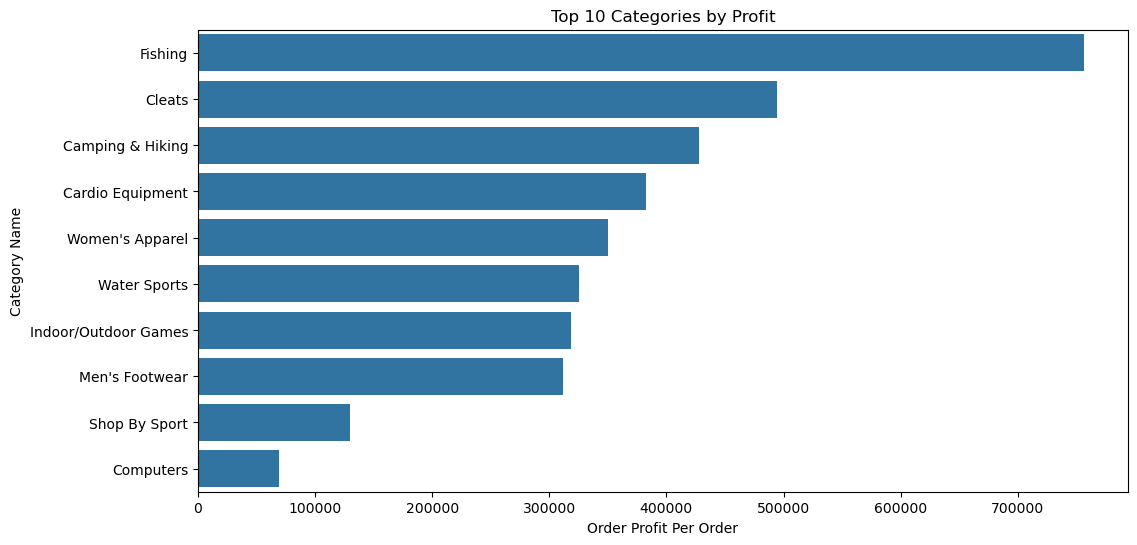

In [59]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_profit_categories.head(10),
    x='Order Profit Per Order',
    y='Category Name'
)

plt.title("Top 10 Categories by Profit")
plt.show()

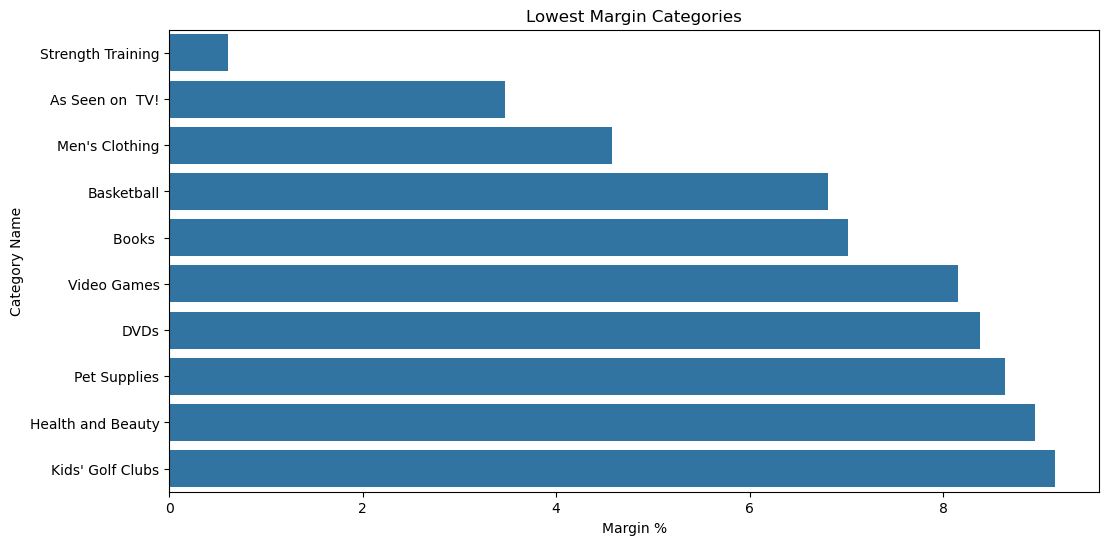

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=lowest_margin_categories.head(10),
    x='Margin %',
    y='Category Name'
)

plt.title("Lowest Margin Categories")
plt.show()

In [63]:
product_analysis = clean_df.groupby(
    'Product Name'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

product_analysis['Margin %'] = (
    product_analysis['Order Profit Per Order']
    /
    product_analysis['Sales']
) * 100

In [64]:
top_products = product_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
)

top_products.head(10)


,Product Name,Sales,Order Profit Per Order,Margin %
24,Field & Stream Sportsman 16 Gun Fire Safe,6929653.50,756220.76,10.912822
71,Perfect Fitness Perfect Rip Deck,4421143.02,493828.30,11.169697
21,Diamondback Women's Serene Classic Comfort Bi,4118425.42,427455.57,10.379102
61,Nike Men's Free 5.0+ Running Shoe,3667633.20,379915.82,10.358610
59,Nike Men's Dri-FIT Victory Golf Polo,3147800.00,350421.03,11.132252
70,Pelican Sunstream 100 Kayak,3099845.00,324076.37,10.454599
67,O'Brien Men's Neoprene Life Vest,2888993.94,318451.43,11.022918
56,Nike Men's CJ Elite 2 TD Football Cleat,2891757.54,311902.82,10.785926
102,Under Armour Girls' Toddler Spine Surge Runni,1269082.65,126278.51,9.950377
18,Dell Laptop,663000.00,69656.81,10.506306


## Product & Category Insights

1. Fishing is the highest revenue and profit-generating category, contributing approximately $6.93 million in sales and $756K in profit.
2. Cleats and Camping & Hiking are also strong contributors to business profitability.
3. Strength Training exhibits an extremely low profit margin (0.61%), making it a potential loss-risk category.
4. Several low-margin categories may require pricing optimization or supplier cost renegotiation.
5. Revenue and profit rankings are closely aligned, indicating that major revenue categories are also delivering strong profitability.

# Discount Impact Analysis

This section evaluates the relationship between discounts and profitability to identify margin erosion caused by aggressive discounting.

In [65]:
discount_corr = clean_df[
    [
        'Order Item Discount Rate',
        'Order Item Profit Ratio'
    ]
].corr()

discount_corr

,Order Item Discount Rate,Order Item Profit Ratio
Order Item Discount Rate,1.000000,-0.002691
Order Item Profit Ratio,-0.002691,1.000000


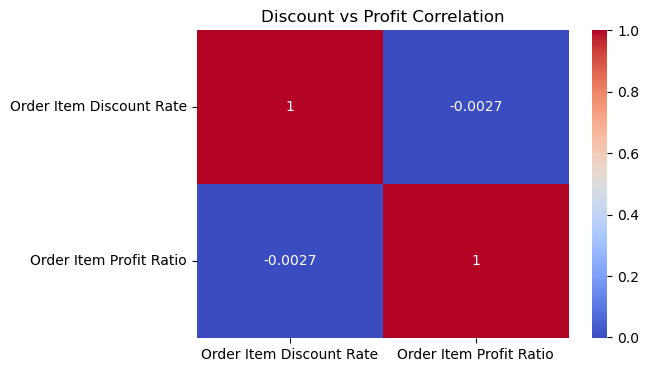

In [66]:
plt.figure(figsize=(6,4))

sns.heatmap(
    discount_corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Discount vs Profit Correlation")
plt.show()

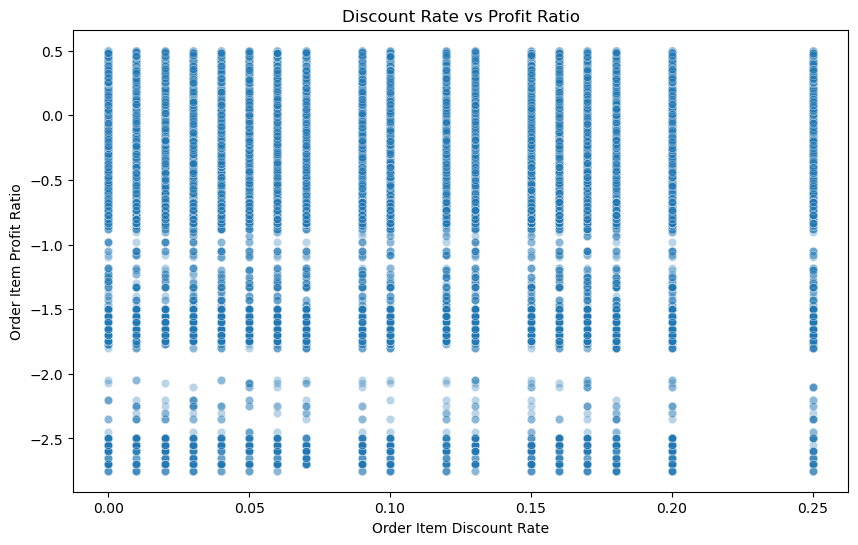

In [67]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=clean_df,
    x='Order Item Discount Rate',
    y='Order Item Profit Ratio',
    alpha=0.3
)

plt.title("Discount Rate vs Profit Ratio")
plt.show()

In [68]:
clean_df['Discount Bucket'] = pd.cut(
    clean_df['Order Item Discount Rate'],
    bins=[0,0.1,0.2,0.3,0.4,1],
    labels=[
        '0-10%',
        '10-20%',
        '20-30%',
        '30-40%',
        '40%+'
    ]
)

In [69]:
clean_df.to_csv(
    "cleaned_APL_Logistics.csv",
    index=False
)

print("CSV updated successfully")

CSV updated successfully


In [70]:
discount_analysis = clean_df.groupby(
    'Discount Bucket'
).agg({
    'Profit Margin %':'mean',
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

discount_analysis

,Discount Bucket,Profit Margin %,Sales,Order Profit Per Order
0,0-10%,11.524813,18389597.73,2098193.71
1,10-20%,9.859074,14308445.10,1409400.14
2,20-30%,9.522186,2044322.34,191896.72
3,30-40%,NaN,0.00,0.00
4,40%+,NaN,0.00,0.00


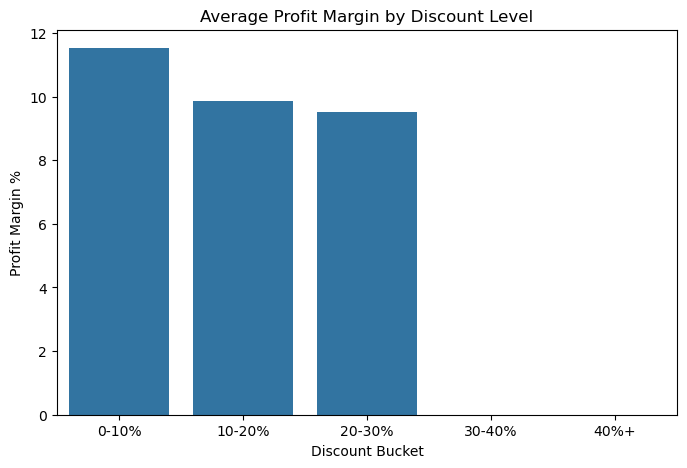

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=discount_analysis,
    x='Discount Bucket',
    y='Profit Margin %'
)

plt.title("Average Profit Margin by Discount Level")
plt.show()

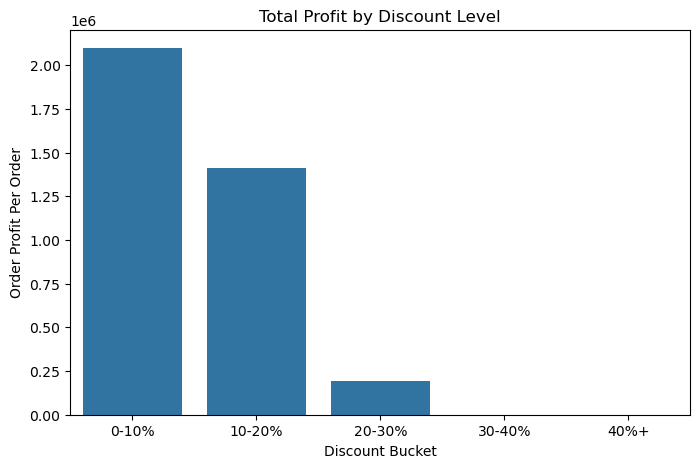

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=discount_analysis,
    x='Discount Bucket',
    y='Order Profit Per Order'
)

plt.title("Total Profit by Discount Level")
plt.show()

## Discount Impact Insights

1. The correlation between discount rate and profit ratio is weak (-0.0027), suggesting that profitability is influenced by multiple business factors beyond discounting alone.

2. Orders with discounts between 0% and 10% generated the highest revenue ($18.39M) and profit ($2.10M).

3. Average profit margin decreased from 11.52% to 9.86% when discounts increased from the 0–10% range to the 10–20% range.

4. Discounts above 20% contribute significantly less revenue while continuing to reduce profitability.

5. The recommended discount threshold for maintaining profitability is below 10%.

# Market & Regional Profitability Analysis

This section evaluates profitability across markets, regions, and countries to identify the strongest and weakest geographical areas.

In [73]:
market_analysis = clean_df.groupby(
    'Market'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

market_analysis['Margin %'] = (
    market_analysis['Order Profit Per Order']
    /
    market_analysis['Sales']
) * 100

market_analysis

,Market,Sales,Order Profit Per Order,Margin %
0,Africa,2294452.88,252071.18,10.986113
1,Europe,10872396.60,1169442.96,10.756073
2,LATAM,10277612.64,1123321.61,10.929791
3,Pacific Asia,8273743.58,857753.44,10.367175
4,USCA,5066528.61,564313.78,11.138075


In [74]:
market_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
)

,Market,Sales,Order Profit Per Order,Margin %
1,Europe,10872396.60,1169442.96,10.756073
2,LATAM,10277612.64,1123321.61,10.929791
3,Pacific Asia,8273743.58,857753.44,10.367175
4,USCA,5066528.61,564313.78,11.138075
0,Africa,2294452.88,252071.18,10.986113


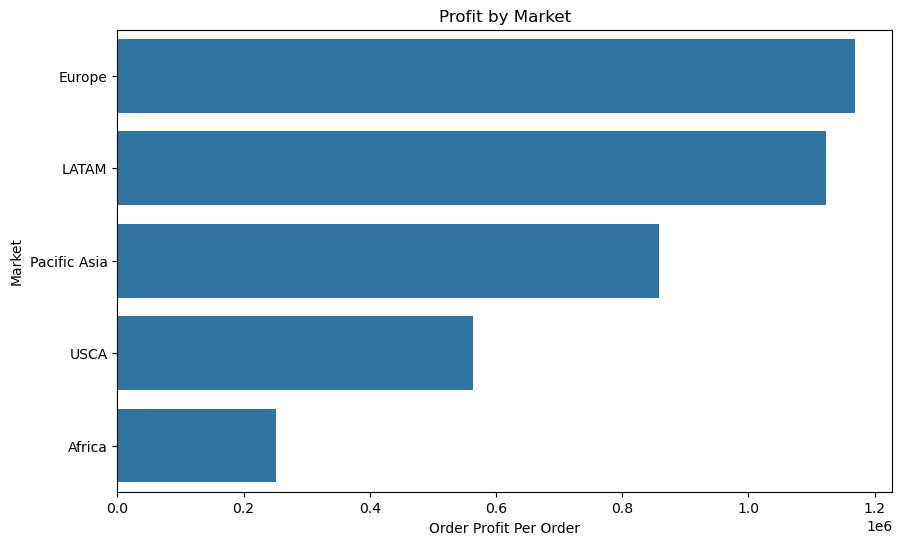

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=market_analysis.sort_values(
        by='Order Profit Per Order',
        ascending=False
    ),
    x='Order Profit Per Order',
    y='Market'
)

plt.title("Profit by Market")
plt.show()

In [76]:
region_analysis = clean_df.groupby(
    'Order Region'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

region_analysis['Margin %'] = (
    region_analysis['Order Profit Per Order']
    /
    region_analysis['Sales']
) * 100

region_analysis

,Order Region,Sales,Order Profit Per Order,Margin %
0,Canada,186861.04,23900.71,12.790633
1,Caribbean,1651019.30,171825.64,10.407246
2,Central Africa,327263.01,33447.27,10.220303
3,Central America,5665711.99,616341.57,10.878449
4,Central Asia,109839.93,13045.28,11.876628
5,East Africa,376234.89,43167.73,11.473612
6,East of USA,1371111.96,156263.30,11.396830
7,Eastern Asia,1486401.31,147368.01,9.914416
8,Eastern Europe,774266.55,79717.05,10.295815
9,North Africa,634752.21,64599.86,10.177178


In [77]:
region_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
).head(10)

,Order Region,Sales,Order Profit Per Order,Margin %
22,Western Europe,5894380.66,625446.08,10.610887
3,Central America,5665711.99,616341.57,10.878449
12,South America,2960881.35,335154.40,11.319413
10,Northern Europe,2155830.61,233450.60,10.828801
17,Southern Europe,2047918.78,230829.23,11.271405
15,Southeast Asia,1932495.53,211342.82,10.936264
11,Oceania,2016654.16,201478.02,9.990708
1,Caribbean,1651019.30,171825.64,10.407246
13,South Asia,1553680.89,165703.90,10.665247
21,West of USA,1571415.93,164940.66,10.496308


In [78]:
country_analysis = clean_df.groupby(
    'Order Country'
).agg({
    'Sales':'sum',
    'Order Profit Per Order':'sum'
}).reset_index()

country_analysis['Margin %'] = (
    country_analysis['Order Profit Per Order']
    /
    country_analysis['Sales']
) * 100

In [79]:
country_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
).head(10)

,Order Country,Sales,Order Profit Per Order,Margin %
48,Estados Unidos,4879667.57,540413.07,11.074793
53,Francia,2879942.31,327828.58,11.383165
102,México,2633195.24,303278.37,11.517504
2,Alemania,2074171.78,194827.08,9.393006
20,Brasil,1594319.92,186713.64,11.711178
120,Reino Unido,1612094.82,180942.88,11.224084
8,Australia,1694621.64,170041.58,10.034191
31,China,1172902.09,122190.92,10.417828
75,Italia,1072181.65,121545.47,11.336276
69,India,962396.68,99746.82,10.364419


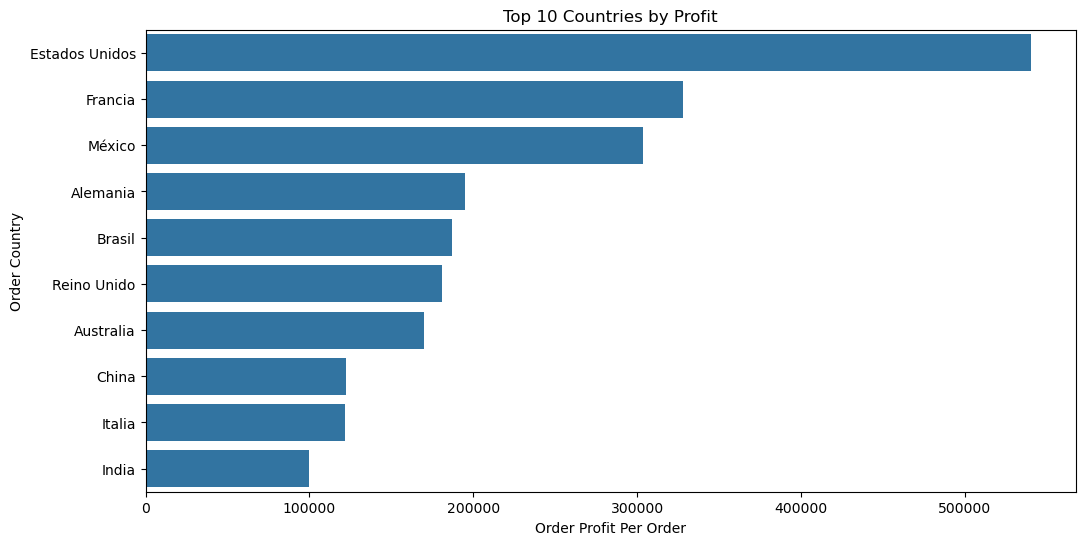

In [80]:
top_countries = country_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_countries,
    x='Order Profit Per Order',
    y='Order Country'
)

plt.title("Top 10 Countries by Profit")
plt.show()

In [81]:
market_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
)

region_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
).head(10)

country_analysis.sort_values(
    by='Order Profit Per Order',
    ascending=False
).head(10)

,Order Country,Sales,Order Profit Per Order,Margin %
48,Estados Unidos,4879667.57,540413.07,11.074793
53,Francia,2879942.31,327828.58,11.383165
102,México,2633195.24,303278.37,11.517504
2,Alemania,2074171.78,194827.08,9.393006
20,Brasil,1594319.92,186713.64,11.711178
120,Reino Unido,1612094.82,180942.88,11.224084
8,Australia,1694621.64,170041.58,10.034191
31,China,1172902.09,122190.92,10.417828
75,Italia,1072181.65,121545.47,11.336276
69,India,962396.68,99746.82,10.364419


## Market & Regional Insights

1. The United States is the largest contributor to both revenue and profit.
2. France and Mexico are strong-performing markets with margins above 11%.
3. Brazil demonstrates the highest profitability among major markets with a margin of 11.71%.
4. Germany generates significant revenue but comparatively lower margins, indicating possible pricing or operational inefficiencies.
5. International markets contribute substantially to overall profitability, highlighting the importance of global diversification.

In [82]:
kpi_summary = pd.DataFrame({
    "KPI":[
        "Total Revenue",
        "Total Profit",
        "Profit Margin (%)",
        "Total Customers",
        "Total Products",
        "Total Categories",
        "Total Markets"
    ],
    "Value":[
        round(clean_df['Sales'].sum(),2),
        round(clean_df['Order Profit Per Order'].sum(),2),
        round(
            (
                clean_df['Order Profit Per Order'].sum()
                /
                clean_df['Sales'].sum()
            )*100,
            2
        ),
        clean_df['Customer Id'].nunique(),
        clean_df['Product Name'].nunique(),
        clean_df['Category Name'].nunique(),
        clean_df['Market'].nunique()
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,36784734.31
1,Total Profit,3966902.97
2,Profit Margin (%),10.78
3,Total Customers,20652.00
4,Total Products,118.00
5,Total Categories,50.00
6,Total Markets,5.00


# Strategic Recommendations

## Customer Strategy

- Retain high-value customers through loyalty and retention programs.
- Review pricing policies for loss-making customers.

## Product Strategy

- Prioritize Fishing, Cleats, and Camping & Hiking categories.
- Investigate Strength Training due to extremely low margins.

## Discount Strategy

- Maintain discounts below 10% whenever possible.
- Closely monitor discounts above 20%.

## Market Strategy

- Continue investment in the United States, France, and Mexico.
- Investigate Germany for margin improvement opportunities.

## Profitability Strategy

- Shift focus from revenue growth to profit optimization.
- Develop customer and category-level profitability monitoring dashboards.

In [83]:
clean_df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Product Price',
 'Shipping Mode',
 'Customer Name',
 'Profit Margin %',
 'Discount %',
 'Shipping Delay',
 'Discount Bucket']